# Task 5
Another popular server provided by the Neher group in Basel (https://covid19-scenarios.org/)
Explain the model and the underlying methods.

## Model

### Idea
The application serves as an interactive planning tool for simulating COVID-19 ourbreaks. It is based on a **Susceptible-Infected-Recovered (SIR)** model but offers variability about an infected individual being infectious, making it a **Susceptible-Exposed-Infected-Recovered (SEIR)** model.

### Application

The model is age-stratified and divides the population into disjunctive compartments (see below). By using a system of **differential equations** (see below), it calculates how many people are in each **compartment** (see below) at each point of time following a predefined tree of possible **developments** (see below) for an individual.

### Assumptions
- Transmissibility of the virus could have seasonal variation
- The ratio of recovery to severity after being infectious depends on the age
- The ratio of recovery to deterioration after being severely sick depends on the age as well
- The ratio of hospitalization to death after being in a ICU depends on the age as well 
- Younger age-groups are given preferential access to ICU (in case of overflow)

### Output
A simulation over time for numbers in the compartments.
Where available, real surveillance data is plottet alongside the simulation to adapt parameters to tune the simulation to the data. Once the model fits past data, the user can explore future scenarios by adjusting
interventions and seasonality.

## Compartments
- $S$ usceptible: people who can get infected
- $E$ xposed: infected but not yet infectious
- $I$ nfectious: people who can infect
- $H$ ospitalized: severe symptoms and in a hospital
- $C$ ritical: people in an Intensive Care Unit (ICU)
- $O$ verflow: in need for ICU but on hold due to capacity problems
- $D$ ead: victims of the virus

## Development
- The $E$ group is split into three stages ($E^1, E^2, E^3$) since realistically not everyone spends the same time being exposed.
- In case of a direct recovery, the progression for an individual is:

    $S\rightarrow E^1\rightarrow E^2\rightarrow E^3\rightarrow I\rightarrow R$

- For severe cases possible branches (including recursiveness) are:

    $I\rightarrow H\rightarrow R$ (hospitalized, then recovered)

    $I\rightarrow H\rightarrow C/O\rightarrow H$ (critical/overflow, back to hospital if survived)

    $I\rightarrow H\rightarrow [C/O]\rightarrow D$ (death after hospital and eventually ICU)

## Parameters (mathematical notation - program notation - explanation)

- **Population**
    - $N_{population}$ - **n** - population size
    - $f_{immune}$ - **pre_immune** - fration of already immune at the begining
    - $f_{infected}$ - **pre_infected** - fraction of already infected at the begining
    - $r_{imports}$  - **daily_imports** - new cases entering from outside per day
    - $N_{hospital}$ - **hospital_beds** - total hospital beds available
    - $N_{icu}$ - **icu_beds** - total icu beds available 

- **Age-group-specific** (per age group $a$)
    - ? - **age_groups** - list where each entry is a range of ages 
    - ? - **age_distribution** - list where each entry is number of people for age_groups
    - ? - **confirmed_frac** - fraction of all infections that are confirmed
    - ? - **mild_frac** - fraction of confirmed that recover without $H$
    - ? - **severe_frac** - fraction of confirmed that require $H$
    - ? - **critical_frac** - fraction of $H$ that go to $C$
    - $f_a$ - **fatal_frac** - fraction of $C$ that go to $D$
    - $\zeta_a$ - **isolation_frac** - fraction of age_distribution isolated from n

- **Epidemiology**
    - $t_{start}, t_{end}$ - **sim_start**, **sim_end** - range of simulation start/end (dates)
    - $R_{0_{min}}, R_{0_{max}}$ - **r0_min**, **r0_max** - range of secondary infections per infected
    - $n_{runs}$ - **n_runs** - number of random samples drawn from the range
    - $t_{latency}$ - **latency** - average days spent in $E$ before $I$
    - $t_{infectious}$ - **infectious** - average days spent in $I$
    - $\epsilon$ - **seasonal** - amplitude of seasonal variation in transmissibility
    - $t_{max}$ - **month_peak** - month of peak transmissibility
    - $t_{hospital}$ - **hospital_days** - average days in hospital $H$
    - $t_{icu}$ - **icu_days** - average days in $C$
    - $\xi$ - **overflow_severity** - mortality multiplier for $O$ vs $C$

- **Mitigation** (per intervention $i$)
    - $I$ - **interventions** - list of interventions at a specific time $t$
    - ? - **inter_name** - name of the intervention
    - ? - **inter_start** - start date
    - ? - **inter_end** - end date
    - ? - **inter_min**, **inter_max** - range of % transmission reduction
    - $e_{i}$ - **inter_efficacy** - sampled transmission reduction for intervention $i$ from range [inter_min, inter_max]

## Differential Equations

### Transmission Rate

$\beta_a(t) = R_0\cdot\zeta_a\cdot M(t)\cdot(1+\epsilon\cdot\cos(2\cdot\pi\cdot(t-t_{max})))/t_i$

where

$M(t) = \prod_{i\in I(t)}(1-e_i) $

computates the combined effect of all active interventions at time $t$.

### ODE System

The full system of differential equations is given in https://covid19-scenarios.org/about. Each equation describes the rate of change of one compartment as the difference between inflow and outflow rates, weighted by the transition parameters (see Parameters: Epidemiology).

## Methods

### Numerical Integration
The ODE system is integrated forward in time using scipy's solve_ivp (RK45 by default) - a method that estimates the rate of change at multiple points within each timestep and adaptively adjusts the stepsize based on the change itself. Note that we already introduced this method in Task_1.

### Parameter Estimation (not coded)
Estimates $R_0, t_{start}, and f_{infected}$ by fitting the model to real surveillance data. This happens in two steps: Least Squares and Nelder-Mead.

#### Least Squares
Runs the ODE simulation with our parameters and returns the sum of squared differences between the simulated trajectories and the reference data.

#### Nelder-Mead
An optimization algorithm that minimizes the results of Least Squares without requiring gradients (e.g., compared to Gradient Descent). It iteratively tries different parameter combinations and moves towards those that reduce the error. Thus, converges to the best fitting parameters.
(Source: https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method)

Reproduce the model and model simulations from the
two models for the COVID-19 epidemiology.

In [18]:
# Imports

import math
import random
import numpy as np
import pandas as pd
from datetime import date
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [27]:
# Parameters

# Population

n = 327167434

pre_immune = 37.4

pre_infected = 0.0037839

daily_imports = 0.1

hospital_beds = 798288

icu_beds = 49499


# Age-specific

# age = [(age_min, age_max), distribution, confirmed(% total), severe(% of confirmed), palliative(% of severe), critical(%of severe), fatal(% of critical), fatal(% of all infecctions), isolated(% of total)]

age_0 = [(0, 9), 39721484, 5, 1, 0, 5, 10, 0, 0]
age_1 = [(10, 19), 42332393, 5, 3, 0, 10, 10, 0, 0]
age_2 = [(20, 29), 46094077, 10, 3, 0, 10, 10, 0, 0]
age_3 = [(30, 39), 44668271, 15, 3, 0, 15, 10, 0.01, 0]
age_4 = [(40, 49), 40348398, 20, 6, 0, 20, 10, 0.02, 0]
age_5 = [(50, 59), 42120077, 20, 10, 0, 25, 20, 0.01, 0]
age_6 = [(60, 69), 38488173, 25, 25, 5, 30, 30, 0.88, 0]
age_7 = [(70, 79), 24082598, 30, 35, 10, 25, 40, 2.1, 0]
age_8 = [(80, 999), 13147180, 40, 50, 20, 15, 40, 5.2, 0]

ages = [age_0, age_1, age_2, age_3, age_4, age_5, age_6, age_7, age_8]

confirmed_frac = None


# Epidemiology

sim_start = date(2021, 4, 13)

sim_end = date(2021, 8, 11)

n_runs = 15

r0_min = 4.08
r0_max = 4.98

r0 = 1 # updated globally for each simulation run

latency = 3

infectious = 3

seasonal = 0 # !!!

month_peak = 15 # !!!

hospital_days = 7

icu_days = 14

overflow_severity = 2


# Mitigation

# intervention = [(inter_start, inter_end), (inter_min, inter_max)]

inter_0 = [(date(2020, 1, 29), date(2020, 2, 20)), (72.6, 83.4)]
inter_1 = [(date(2020, 2, 20), date(2020, 3, 24)), (1, 1)]
inter_2 = [(date(2020, 3, 24), date(2020, 4, 18)), (57.1, 68.9)]
inter_3 = [(date(2020, 4, 18), date(2020, 5, 9)), (61.1, 72.9)]
inter_4 = [(date(2020, 5, 9), date(2020, 6, 6)), (59.1, 70.9)]
inter_5 = [(date(2020, 6, 6), date(2020, 7, 11)), (52.3, 63.7)]
inter_6 = [(date(2020, 7, 11), date(2020, 8, 7)), (61.1, 72.9)]
inter_7 = [(date(2020, 8, 7), date(2020, 9, 4)), (61.1, 72.9)]
inter_8 = [(date(2020, 9, 4), date(2020, 9, 26)), (57.1, 68.9)]
inter_9 = [(date(2020, 9, 26), date(2020, 10, 21)), (54.2, 65.8)]
inter_10 = [(date(2020, 10, 21), date(2020, 11, 11)), (51.4, 61.6)]
inter_11 = [(date(2020, 11, 11), date(2020, 12, 3)), (57.1, 68.9)]
inter_12 = [(date(2020, 12, 3), date(2021, 1, 3)), (58.1, 69.9)]
inter_13 = [(date(2021, 1, 3), date(2021, 2, 12)), (65.2, 76.8)]
inter_14 = [(date(2021, 2, 12), date(2021, 3, 6)), (60.1, 71.9)]
inter_15 = [(date(2021, 3, 6), date(2021, 4, 8)), (57.1, 68.9)]
inter_16 = [(date(2021, 4, 8), date(2021, 4, 29)), (63.1, 74.9)]
inter_17 = [(date(2021, 4, 29), date(2021, 5, 23)), (65.2, 76.8)]
inter_18 = [(date(2021, 5, 23), date(2021, 6, 13)), (62.1, 73.9)]
inter_19 = [(date(2021, 6, 13), date(2021, 8, 12)), (53.3, 64.7)]

interventions = [inter_0, inter_1, inter_2, inter_3, inter_4, inter_5, inter_6, inter_7, inter_8, inter_9, inter_10, inter_11, inter_12, inter_13, inter_14, inter_15, inter_16, inter_17, inter_18, inter_19]

def date_to_day(d):
    return (d - sim_start).days

interventions = [
    [(date_to_day(inter[0][0]), date_to_day(inter[0][1])), inter[1]]
    for inter in interventions
]



In [28]:
# Methods

def initial_state(age):
    '''
    Builds the compartments for an age group at the simulation start
    '''
    n_age = age[1] # number of people in age group

    infected = pre_infected * n_age / n
    immune = pre_immune * n_age / n
    susceptible = n_age - infected - immune

    # S, E1, E2, E3, I, H, C, O, R, D
    return [susceptible, 0, 0, 0, infected, 0, 0, 0, immune, 0]

def get_compartment(results_array, compartment_idx):
    """
    Sum compartment across all age groups, for each run.
    Returns array of shape (n_runs, n_days)
    """
    total = None

    for a in range(len(ages)):

        idx = a * 10 + compartment_idx

        if total is None:
            total = results_array[:, idx, :]

        else:
            total += results_array[:, idx, :]
            
    return total

def seasonal_factor(t):
    '''
    Returns the seasonal factor for transmission
    '''
    return 1 + seasonal * math.cos(2 * math.pi * (t - month_peak) / 365)

def M(t):
    
    result = 1.0

    for intervention in interventions:

        if intervention[0][0] <= t <= intervention[0][1]:
            
            efficacy = random.uniform(intervention[1][0], intervention[1][1]) / 100
            result *= (1 - efficacy)

    return result

def trans_rate(a, t):
    '''
    Input: age group, time (date)
    Output: transmission rate for age group at time
    '''

    isolation_frac = ages[a][-1] / 100
    
    return r0 * isolation_frac * M(t) * (1 + seasonal_factor(t) * math.cos(2 * math.pi * (t - month_peak) / 365)) / infectious

In [29]:
# Differential Equations (AI generated)

def ode_system(t, y):

    dydt = [0.0] * (len(ages) * 10)

    # total infectious across all age groups
    I_total = sum(y[b * 10 + 4] for b in range(len(ages)))

    # total critical across all age groups (for ICU capacity check)
    C_total = sum(y[b * 10 + 6] for b in range(len(ages)))

    for a in range(len(ages)):

        S  = y[a * 10 + 0]
        E1 = y[a * 10 + 1]
        E2 = y[a * 10 + 2]
        E3 = y[a * 10 + 3]
        I  = y[a * 10 + 4]
        H  = y[a * 10 + 5]
        C  = y[a * 10 + 6]
        O  = y[a * 10 + 7]
        R  = y[a * 10 + 8]
        D  = y[a * 10 + 9]

        # age specific fractions (converting % to 0-1)
        confirmed = ages[a][2] / 100
        severe    = ages[a][3] / 100
        critical  = ages[a][5] / 100
        fatal     = ages[a][6] / 100
        mild      = 1 - severe  # fraction that recover without H

        beta = trans_rate(a, t)
        ge = 1 / latency      # rate through E stages
        gi = 1 / infectious   # rate out of I
        gh = 1 / hospital_days
        gc = 1 / icu_days

        # ICU capacity check (Heaviside step function)
        icu_available = C_total < icu_beds

        # dS/dt
        dydt[a * 10 + 0] = -beta * S * I_total

        # dE1/dt
        dydt[a * 10 + 1] = beta * S * I_total - 3 * ge * E1

        # dE2/dt
        dydt[a * 10 + 2] = 3 * ge * E1 - 3 * ge * E2

        # dE3/dt
        dydt[a * 10 + 3] = 3 * ge * E2 - 3 * ge * E3

        # dI/dt
        dydt[a * 10 + 4] = 3 * ge * E3 - gi * I

        # dH/dt
        dydt[a * 10 + 5] = (severe * gi * I
                           + gc * (1 - fatal) * (C + overflow_severity * O)
                           - gh * H)

        # dC/dt (only if ICU available)
        dydt[a * 10 + 6] = (critical * gh * H * icu_available
                           - gc * C)

        # dO/dt (overflow: ICU needed but not available)
        dydt[a * 10 + 7] = (critical * gh * H * (not icu_available)
                           - (1 + (overflow_severity - 1) * fatal) * gc * O)

        # dR/dt
        dydt[a * 10 + 8] = mild * gi * I + (1 - critical) * gh * H

        # dD/dt
        dydt[a * 10 + 9] = fatal * gc * (C + overflow_severity * O)

    return dydt

In [30]:
# Simulation Loop

t_start = 0
t_end = (sim_end - sim_start).days

# Step frequency (for consistent plotting)
t_eval = np.arange(t_start, t_end)

# y0 is the initial number of people in each compartment at t=0
y0 = []
for age in ages:
    y0 += initial_state(age)

# results is a list of n_runs arrays, each of shape (age_groups*compartments, n_days)
results = []

for _ in range(n_runs):

    r0 = random.uniform(r0_min, r0_max)

    solution = solve_ivp(
        fun = ode_system,
        t_span = (t_start, t_end),
        y0 = y0,
        t_eval = t_eval,
    )

    results.append(solution.y)

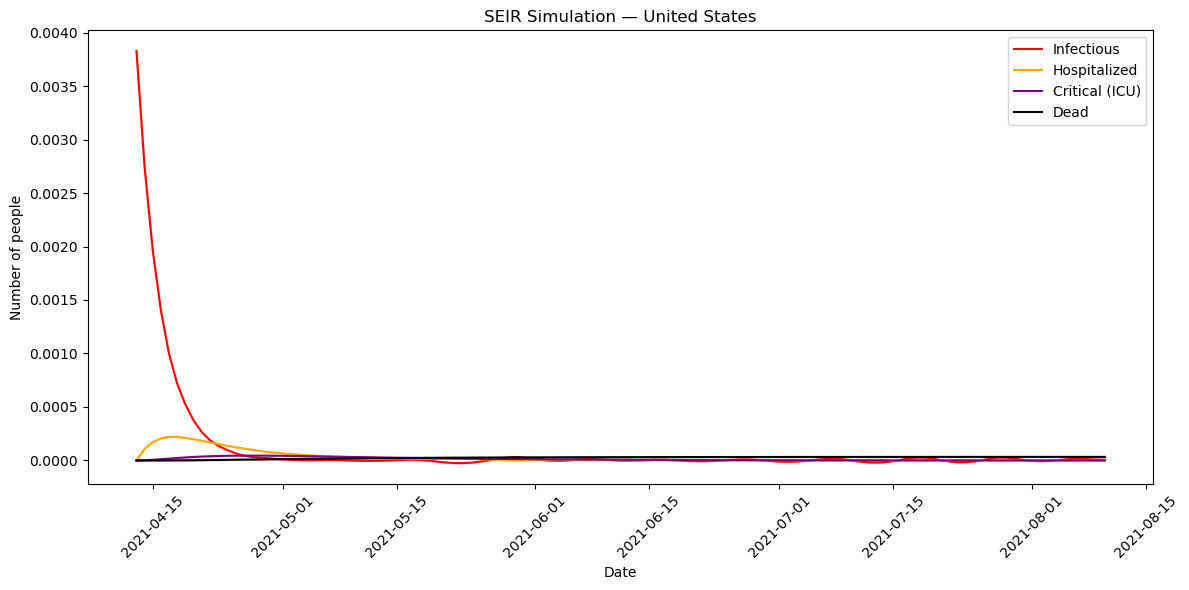

In [31]:
# Plotting

# stack the result list into an array of shape (n_runs, 90, n_days)
result_array = np.array(results)

# extract compartments of intersts (refer to y0 order)
I_runs = get_compartment(result_array, 4)  # infectious
H_runs = get_compartment(result_array, 5)  # hospitalized
C_runs = get_compartment(result_array, 6)  # critical
D_runs = get_compartment(result_array, 9)  # dead

# compute median and 20th/80th percentiles across runs
def get_stats(runs):
    """
    Returns median, 20th and 80th percentile across n_runs
    """

    median = np.percentile(runs, 50, axis=0)
    low    = np.percentile(runs, 20, axis=0)
    high   = np.percentile(runs, 80, axis=0)

    return median, low, high

# time axis in actual dates
dates = pd.date_range(sim_start, sim_end - pd.Timedelta(days=1))

# plot
fig, ax = plt.subplots(figsize=(12, 6))

for runs, label, color in [
    (I_runs, 'Infectious',    'red'),
    (H_runs, 'Hospitalized',  'orange'),
    (C_runs, 'Critical (ICU)','purple'),
    (D_runs, 'Dead',          'black'),
]:
    median, low, high = get_stats(runs)
    
    # solid line = median trajectory
    ax.plot(dates, median, label=label, color=color)
    
    # shaded area = 20th to 80th percentile (uncertainty band)
    ax.fill_between(dates, low, high, alpha=0.2, color=color)

ax.set_xlabel('Date')
ax.set_ylabel('Number of people')
ax.set_title('SEIR Simulation — United States')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
